### Can institutional characteristics & performance indicators predict sustainability performance?



#### Import Libraries

In [86]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

#### Load Data

In [87]:
df = pd.read_csv("QS_DATASET.csv", encoding='latin-1')

print(df.shape)
df.head()

print(df.columns.tolist())
target = "Sustainability_Score"

(1503, 28)
['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region', 'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score', 'Academic_Reputation_Rank', 'Employer_Reputation_Score', 'Employer_Reputation_Rank', 'Faculty_Student_Score', 'Faculty_Student_Rank', 'Citations_per_Faculty_Score', 'Citations_per_Faculty_Rank', 'International_Faculty_Score', 'International_Faculty_Rank', 'International_Students_Score', 'International_Students_Rank', 'International_Research_Network_Score', 'International_Research_Network_Rank', 'Employment_Outcomes_Score', 'Employment_Outcomes_Rank', 'Sustainability_Score', 'Sustainability_Rank', 'Overall_Score']


#### Distribution of Sustainability Scores

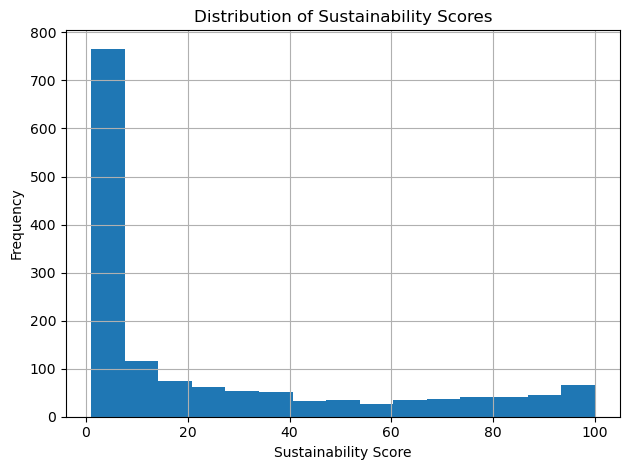

In [88]:
y = df[target]
y.hist(bins=15)
plt.title("Distribution of Sustainability Scores")
plt.xlabel("Sustainability Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Select and Distinguish Features

In [89]:
features = [
    # Institutional characteristics

    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS",

    # Performance indicators

    "Academic_Reputation_Score",
    "Employer_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score"
]
X = df[features]
y = df[target]

numeric_features = [

    "Academic_Reputation_Score",
    "Employer_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score"
]

categorical_features = [

    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS"
]


#### Sanitisation and Pre-Processing

In [90]:
df["Sustainability_Score"] = pd.to_numeric(
    df["Sustainability_Score"],
    errors="coerce"
)

mask = df["Sustainability_Score"].notna()
X = X[mask]
y = df.loc[mask, "Sustainability_Score"]
print(y.isna().sum())



top25 = df["Sustainability_Score"].quantile(0.75)

df["Sustainability_Leader"] = (
    df["Sustainability_Score"] >= top25
).astype(int)

y2 = df.loc[mask, "Sustainability_Leader"].astype(int)




numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

0


#### Train-Test Split

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y2,
    test_size=0.2,
    #stratify=y2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1187, 13)
(297, 13)


#### Random Forest Model

In [92]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_reg)
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_clf)
    ]
)

#### Train Model and Make Predictions

In [93]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

#### Evaluate Model

In [94]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R^2:", round(r2,3))
print("RMSE:", round(rmse,3))
print("MAE:", round(mae,3))



accuracy = accuracy_score(y_test2, y_pred2)
cm = confusion_matrix(y_test2, y_pred2)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print(classification_report(y_test2, y_pred2))

probabilities = model2.predict_proba(X_test2)[:,1]
auc = roc_auc_score(y_test2, probabilities)

print("AUC:", auc)

R^2: 0.757
RMSE: 15.499
MAE: 10.754
Accuracy: 0.9124579124579124
Confusion Matrix:
 [[213  11]
 [ 15  58]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       224
           1       0.84      0.79      0.82        73

    accuracy                           0.91       297
   macro avg       0.89      0.87      0.88       297
weighted avg       0.91      0.91      0.91       297

AUC: 0.9656005381604696


#### Cross-Validation

In [95]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)
print("Average CV R²:", cv_scores.mean())

[-0.59523514  0.26274647 -0.23000002 -0.13429735 -0.82217228]
Average CV R²: -0.3037916640796112


#### Hyperparameter Tuning

In [96]:
param_grid = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,None],
    "model__min_samples_leaf":[1,2,4]
}

param_reg = param_grid.copy()
param_reg["model__min_samples_split"] = [2,5,10]
param_clf = param_grid.copy()
param_clf["model__class_weight"] = [None, "balanced"]

grid = GridSearchCV(
    model,
    param_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)
print(grid.best_params_)

grid2 = GridSearchCV(
    model2,
    param_clf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid2.fit(X_train2,y_train2)
print(grid2.best_params_)

{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}


#### Re-Evaluate on Tuned Parameters

In [97]:
best_model = grid.best_estimator_
best_predictions = best_model.predict(X_test)

best_model2 = grid2.best_estimator_
best_predictions2 = best_model2.predict(X_test2)

r2 = r2_score(y_test,best_predictions)
rmse = np.sqrt(mean_squared_error(y_test,best_predictions))
mae = mean_absolute_error(y_test,best_predictions)

print("Final R^2:",round(r2,3))
print("Final RMSE:",round(rmse,3))
print("Final MAE:",round(mae,3))



accuracy2 = accuracy_score(y_test2, best_predictions2)
cm2 = confusion_matrix(y_test2, best_predictions2)

print("Accuracy:", accuracy2)
print("Confusion Matrix:\n", cm2)
print(classification_report(y_test2, best_predictions2))

probabilities = model2.predict_proba(X_test2)[:,1]
auc = roc_auc_score(y_test2, probabilities)

print("AUC:", auc)

Final R^2: 0.756
Final RMSE: 15.532
Final MAE: 10.706
Accuracy: 0.9225589225589226
Confusion Matrix:
 [[212  12]
 [ 11  62]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       224
           1       0.84      0.85      0.84        73

    accuracy                           0.92       297
   macro avg       0.89      0.90      0.90       297
weighted avg       0.92      0.92      0.92       297

AUC: 0.9656005381604696


#### Feature Importance

                         Grouped_Feature  Importance
0              Academic_Reputation_Score    0.494932
7   International_Research_Network_Score    0.157562
1            Citations_per_Faculty_Score    0.077304
6            International_Faculty_Score    0.070815
8           International_Students_Score    0.056872
2              Employer_Reputation_Score    0.042373
4                  Faculty_Student_Score    0.029511
3              Employment_Outcomes_Score    0.024826
9                                 Region    0.019287
11                                  Size    0.012899
5                                  Focus    0.009904
12                                Status    0.002199
10                    Research Intensity    0.001516


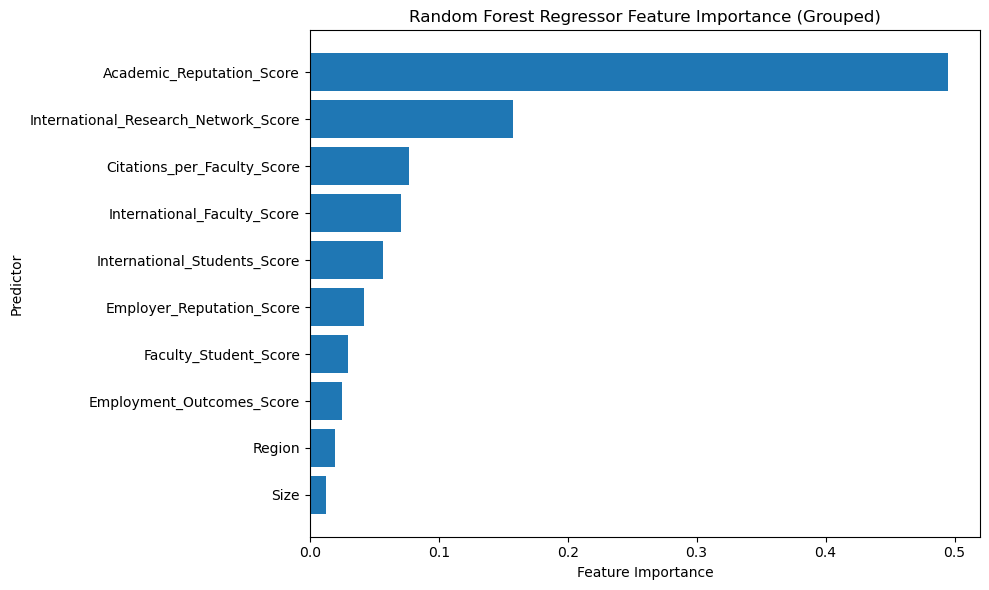

                         Grouped_Feature  Importance
7   International_Research_Network_Score    0.192739
0              Academic_Reputation_Score    0.155708
1            Citations_per_Faculty_Score    0.115056
2              Employer_Reputation_Score    0.111929
8           International_Students_Score    0.090161
3              Employment_Outcomes_Score    0.087016
6            International_Faculty_Score    0.073702
4                  Faculty_Student_Score    0.048457
9                                 Region    0.034206
10                    Research Intensity    0.029099
5                                  Focus    0.028951
11                                  Size    0.024786
12                                Status    0.008190


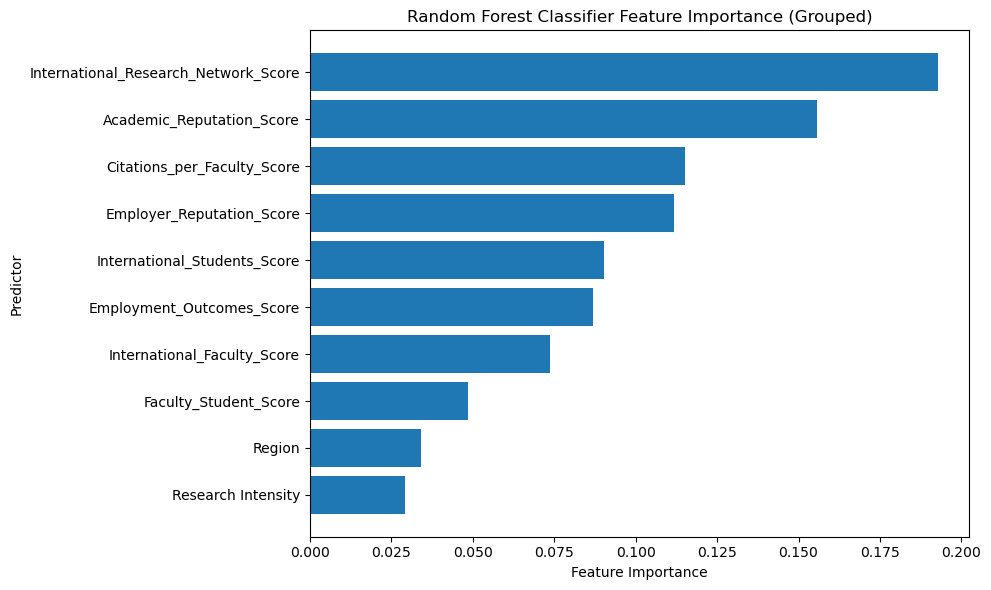

                         Grouped_Feature  Percent
7   International_Research_Network_Score    19.27
0              Academic_Reputation_Score    15.57
1            Citations_per_Faculty_Score    11.51
2              Employer_Reputation_Score    11.19
8           International_Students_Score     9.02
3              Employment_Outcomes_Score     8.70
6            International_Faculty_Score     7.37
4                  Faculty_Student_Score     4.85
9                                 Region     3.42
10                    Research Intensity     2.91
5                                  Focus     2.90
11                                  Size     2.48
12                                Status     0.82


In [98]:
encoder = best_model.named_steps["preprocessor"]\
                    .named_transformers_["cat"]\
                    .named_steps["encoder"]

cat_names = encoder.get_feature_names_out(categorical_features)
feature_names = np.concatenate([
    numeric_features,
    cat_names
])

importances = model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

def group_feature(feature):
    if feature.startswith("Region"):
        return "Region"
    elif feature.startswith("SIZE"):
        return "Size"
    elif feature.startswith("FOCUS"):
        return "Focus"
    elif feature.startswith("RES"):
        return "Research Intensity"
    elif feature.startswith("STATUS"):
        return "Status"
    else:
        return feature

importance_df["Grouped_Feature"] = (
    importance_df["Feature"]
    .apply(group_feature)
)

grouped_importance = (
    importance_df
    .groupby("Grouped_Feature")["Importance"]
    .sum()
    .reset_index()
)

grouped_importance = grouped_importance.sort_values(
    by="Importance",
    ascending=False
)

print(grouped_importance)
top = grouped_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top["Grouped_Feature"],
    top["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Regressor Feature Importance (Grouped)")
plt.tight_layout()
plt.show()


importances2 = model2.named_steps["model"].feature_importances_
importance_df2 = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances2
})

def group_feature(feature):
    if feature.startswith("Region"):
        return "Region"
    elif feature.startswith("SIZE"):
        return "Size"
    elif feature.startswith("FOCUS"):
        return "Focus"
    elif feature.startswith("RES"):
        return "Research Intensity"
    elif feature.startswith("STATUS"):
        return "Status"
    else:
        return feature

importance_df2["Grouped_Feature"] = (
    importance_df2["Feature"]
    .apply(group_feature)
)

grouped_importance2 = (
    importance_df2
    .groupby("Grouped_Feature")["Importance"]
    .sum()
    .reset_index()
)

grouped_importance2 = grouped_importance2.sort_values(
    by="Importance",
    ascending=False
)

print(grouped_importance2)
top2 = grouped_importance2.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top2["Grouped_Feature"],
    top2["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Classifier Feature Importance (Grouped)")
plt.tight_layout()
plt.show()

grouped_importance2["Percent"] = (
    grouped_importance2["Importance"]
    / grouped_importance2["Importance"].sum()
    * 100
)

print(
    grouped_importance2[
        ["Grouped_Feature", "Percent"]
    ].round(2)
)

#### Plot Tree Examples

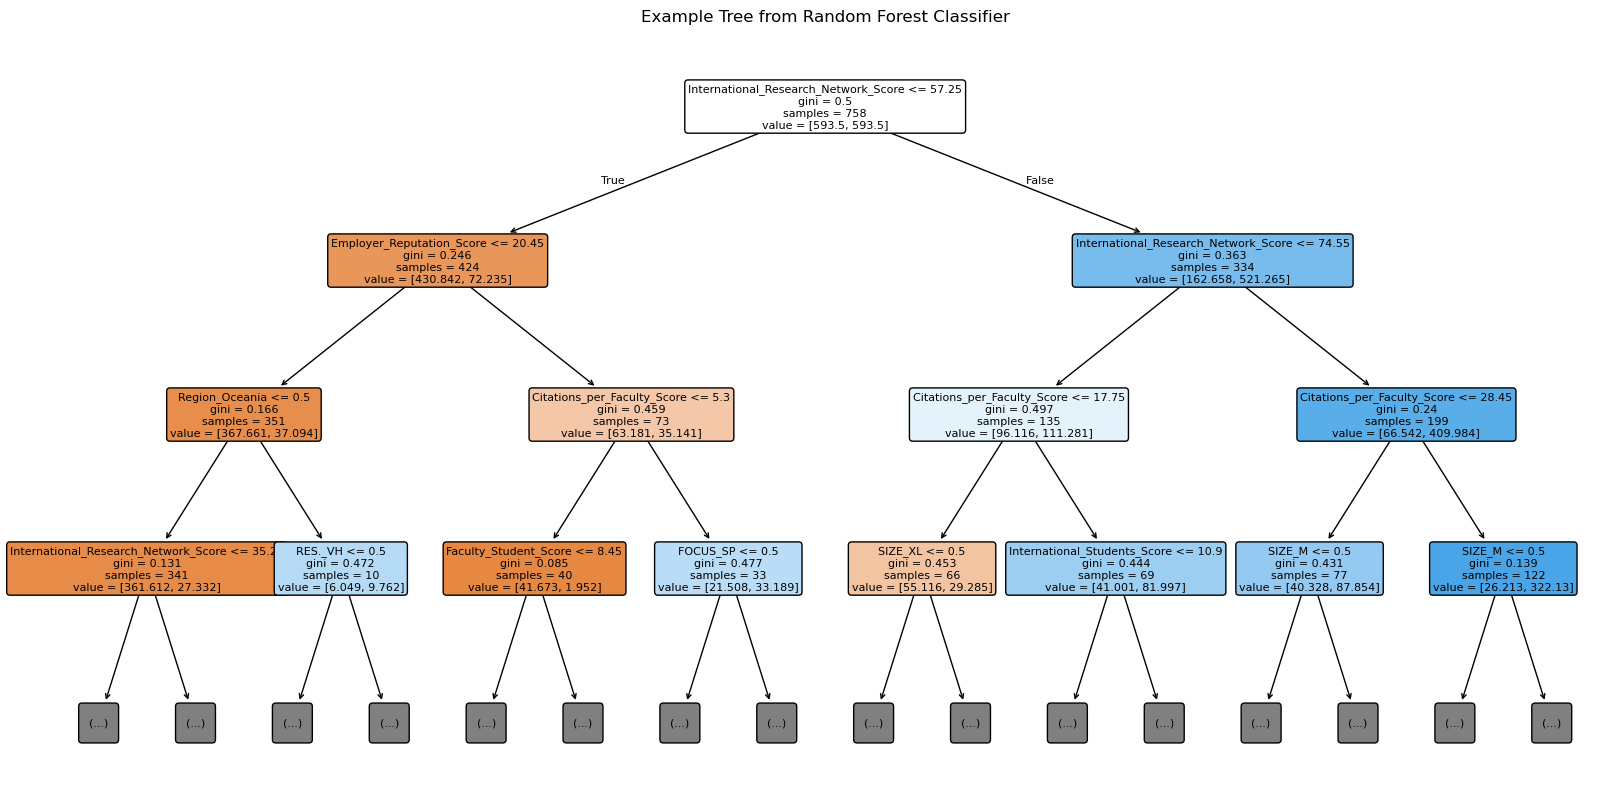

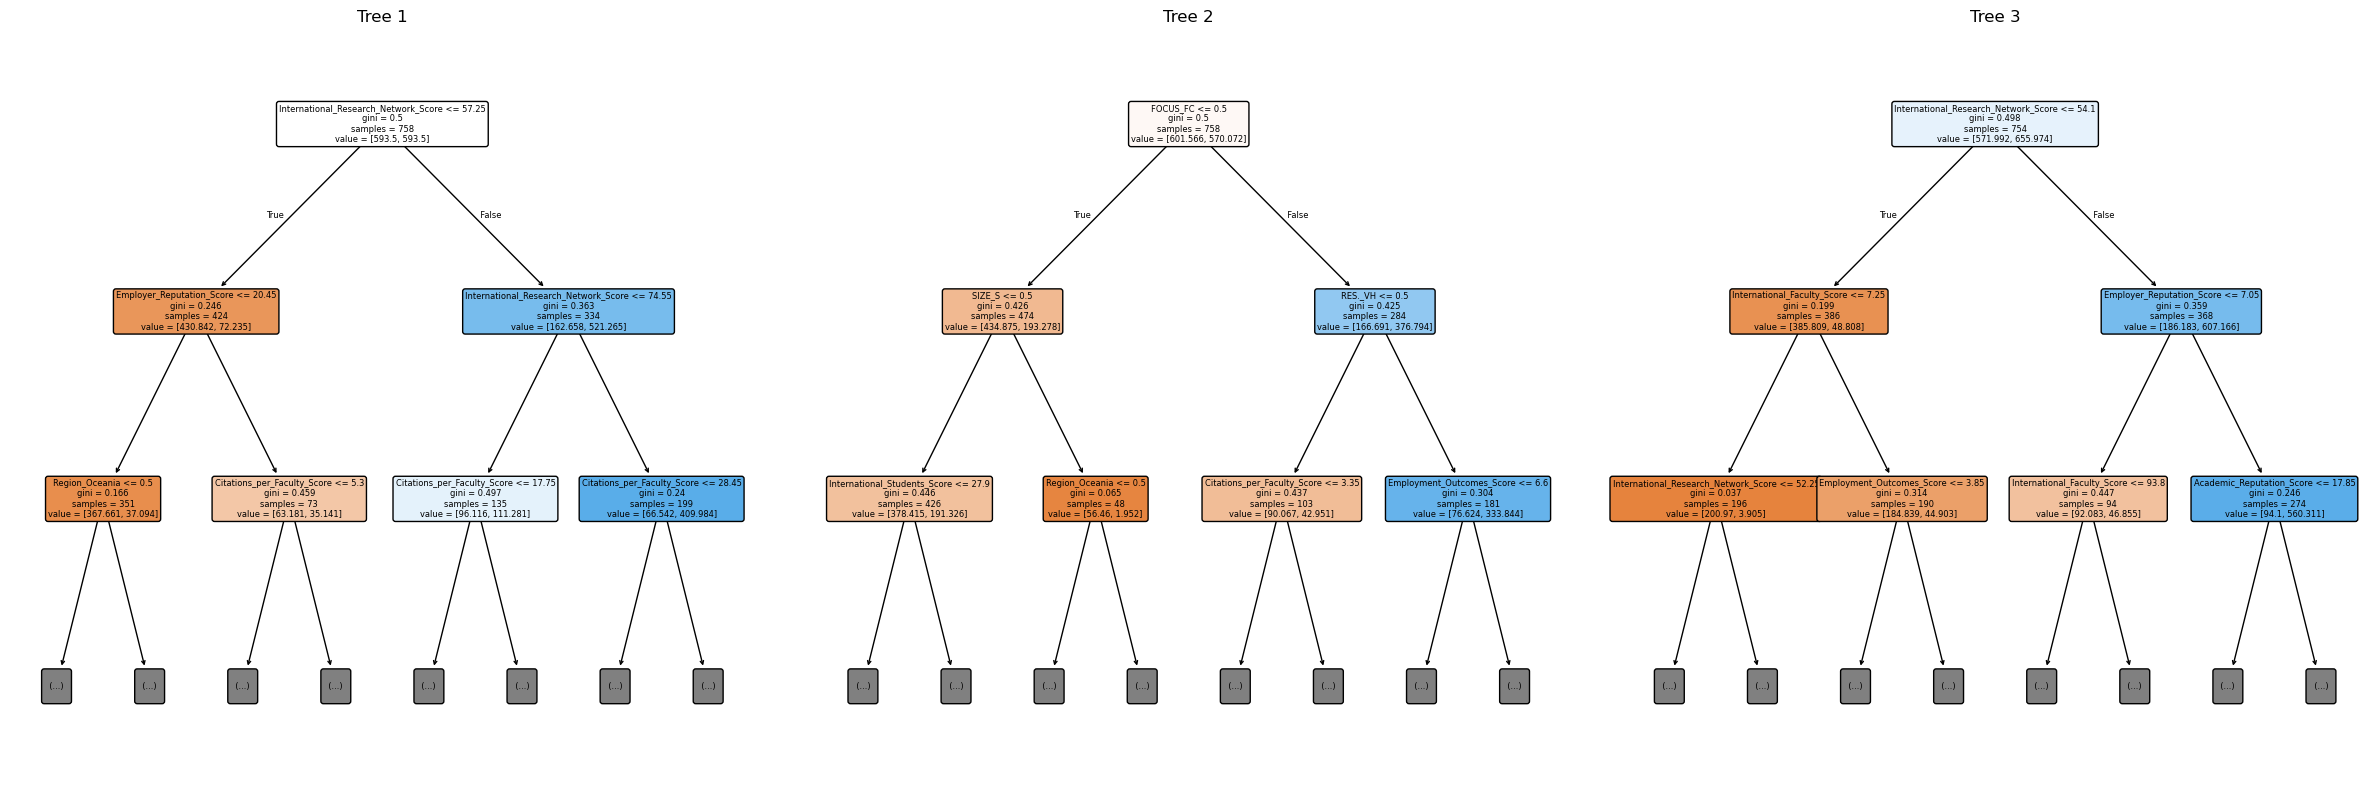

In [99]:
forest = model2.named_steps["model"]
tree = forest.estimators_[0]

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Example Tree from Random Forest Classifier")
plt.show()

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(24,8)
)

for i in range(3):

    plot_tree(
        forest.estimators_[i],
        max_depth=2,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        fontsize=6,
        ax=axes[i]
    )

    axes[i].set_title(f"Tree {i+1}")

plt.tight_layout()
plt.show()